In [21]:
from sklearn import datasets

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_predict


In [10]:
digits = datasets.load_digits()
n_samples = len(digits.images)
X = digits.images.reshape((n_samples, -1))
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

In [16]:
classifier_pipeline = Pipeline([
    ("preprocessing", StandardScaler()),
    ("model", SVC(C=1)), # place holder model
])

param_search = [
    {
        "model": [SVC()],
        "model__kernel": ["rbf", "linear"],
        "model__gamma": [1e-3, 1e-4],
        "model__C": [1, 10, 100, 1000]
    },
]

clf = GridSearchCV(classifier_pipeline, param_search, cv=5, scoring='f1_macro')
clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...', SVC(C=1))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [SVC()], 'model__C': [1, 10, ...], 'model__gamma': [0.001, 0.0001], 'model__kernel': ['rbf', 'linear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramet

In [18]:
clf.best_params_

{'model': SVC(),
 'model__C': 100,
 'model__gamma': 0.001,
 'model__kernel': 'rbf'}

In [20]:
svc_classifier_pipeline = Pipeline([
    ("preprocessing", StandardScaler()),
    ("model", SVC(kernel='rbf',C=100, gamma=0.001))
])

svc_classifier_pipeline.fit(X_train, y_train)

y_pred = svc_classifier_pipeline.predict(X_test)
score = svc_classifier_pipeline.score(X_test, y_test)
print(f"{score:.3f}")
print(classification_report(y_test, y_pred))

0.976
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        82
           1       0.96      0.99      0.97        89
           2       0.99      1.00      0.99        83
           3       0.98      0.96      0.97        93
           4       0.99      1.00      0.99        93
           5       0.99      0.96      0.97        99
           6       0.99      0.98      0.98        98
           7       0.97      0.99      0.98        87
           8       0.94      0.93      0.93        83
           9       0.98      0.96      0.97        92

    accuracy                           0.98       899
   macro avg       0.98      0.98      0.98       899
weighted avg       0.98      0.98      0.98       899



<Figure size 620x440 with 0 Axes>

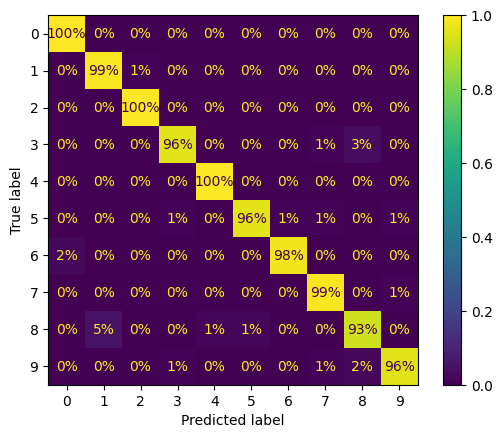

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6.2, 4.4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="true", values_format=".0%"
    )
plt.show()